# 🏎️ F1 2025: Abu Dhabi Grand Prix - Complete Weekend Analysis

**A Deep Dive into One of F1's Most Exciting Weekends**

by Ibrahim | Data Analysis Portfolio Project

---

## 🎯 Why Abu Dhabi GP?

The 2025 Abu Dhabi Grand Prix represents the ultimate F1 showdown:
- **Twilight circuit** with the unique challenge of racing from day into night
- **Dropping track temperatures** significantly affecting tire grip and strategy  
- **Two long DRS straights** creating prime overtaking opportunities
- **High-stakes season finale** that served as a massive three-way Championship decider

This analysis will explore:
1. 📊 Qualifying Performance & Gaps
2. 🏁 Race Strategy & Pace Analysis  
3. 🔧 Telemetry Deep Dive
4. 🏆 Driver & Team Comparisons
5. 💡 Key Insights & Takeaways

---

In [46]:
# Install if needed (uncomment and run once)
!pip install fastf1 pandas numpy matplotlib seaborn plotly kaleido

In [47]:
# Import libraries
import fastf1
import fastf1.plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib.collections import LineCollection
from matplotlib import cm
import warnings
warnings.filterwarnings('ignore')

# Enable cache for faster reloading
# fastf1.Cache.enable_cache('f1_cache')

# Setup F1 plotting
fastf1.plotting.setup_mpl(misc_mpl_mods=False, color_scheme='fastf1')

# Plot styling
plt.style.use('bmh')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['figure.dpi'] = 100

print("✅ Libraries loaded successfully!")
print(f"FastF1 version: {fastf1.__version__}")

✅ Libraries loaded successfully!
FastF1 version: 3.8.1


## 📥 Data Loading

Loading Abu Dhabi Grand Prix 2023 data - Qualifying and Race sessions

In [48]:
# Load Abu Dhabi GP 2025 sessions
print("Loading Abu Dhabi Grand Prix 2025...\n")

# Qualifying session
print("📊 Loading Qualifying...")
quali = fastf1.get_session(2025, 'Abu Dhabi', 'Q')
quali.load()
print(f"✓ Qualifying loaded: {len(quali.laps)} laps recorded")

# Race session
print("\n🏁 Loading Race...")
race = fastf1.get_session(2025, 'Abu Dhabi', 'R')
race.load()
print(f"✓ Race loaded: {len(race.laps)} laps recorded")

print("\n🎉 Data loading complete!")

core           INFO 	Loading data for Abu Dhabi Grand Prix - Qualifying [v3.8.1]
INFO:fastf1.fastf1.core:Loading data for Abu Dhabi Grand Prix - Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
DEBUG:fastf1.ergast:Failed to parse timestamp '' in Ergastresponse.
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data
core           INFO 	Processing timin

Loading Abu Dhabi Grand Prix 2025...

📊 Loading Qualifying...


req            INFO 	Using cached data for car_data
INFO:fastf1.fastf1.req:Using cached data for car_data
req            INFO 	Using cached data for position_data
INFO:fastf1.fastf1.req:Using cached data for position_data
req            INFO 	Using cached data for weather_data
INFO:fastf1.fastf1.req:Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
INFO:fastf1.fastf1.req:Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '81', '63', '16', '14', '5', '31', '6', '22', '87', '55', '30', '12', '18', '44', '23', '27', '10', '43']
INFO:fastf1.fastf1.core:Finished loading data for 20 drivers: ['1', '4', '81', '63', '16', '14', '5', '31', '6', '22', '87', '55', '30', '12', '18', '44', '23', '27', '10', '43']
core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.8.1]
INFO:fastf1.fastf1.core:Loading data for Abu Dhabi Grand Prix - Race [v3.8.1]
req            INFO 	Usi

✓ Qualifying loaded: 286 laps recorded

🏁 Loading Race...


req            INFO 	Using cached data for car_data
INFO:fastf1.fastf1.req:Using cached data for car_data
req            INFO 	Using cached data for position_data
INFO:fastf1.fastf1.req:Using cached data for position_data
req            INFO 	Using cached data for weather_data
INFO:fastf1.fastf1.req:Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
INFO:fastf1.fastf1.req:Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '4', '16', '63', '14', '31', '44', '27', '18', '5', '87', '55', '22', '12', '23', '6', '30', '10', '43']
INFO:fastf1.fastf1.core:Finished loading data for 20 drivers: ['1', '81', '4', '16', '63', '14', '31', '44', '27', '18', '5', '87', '55', '22', '12', '23', '6', '30', '10', '43']


✓ Race loaded: 1156 laps recorded

🎉 Data loading complete!


---
# 1️⃣ Qualifying Analysis

## 🏎️ Q3 Results - The Pole Position Battle

In [49]:
# Use the 'results' DataFrame instead of 'laps' to get official Q1/Q2/Q3 times
results = quali.results.copy()

# Filter for drivers who made it to Q3 (their 'Q3' time is not null)
fastest_q3 = results[results['Q3'].notna()].copy()

# Sort by Q3 time
fastest_q3 = fastest_q3.sort_values('Q3').reset_index(drop=True)

# Convert lap time to seconds for gap calculation
fastest_q3['Q3Seconds'] = fastest_q3['Q3'].dt.total_seconds()
pole_time = fastest_q3['Q3Seconds'].iloc[0]
fastest_q3['GapToPole'] = fastest_q3['Q3Seconds'] - pole_time

print("🏆 Abu Dhabi 2025 - QUALIFYING RESULTS (Q3)")
print("="*70)
print(f"{'Pos':<4} {'Driver':<6} {'Team':<20} {'Q3 Time':<12} {'Gap'}")
print("="*70)

for idx, row in fastest_q3.head(10).iterrows():
    gap_str = f"+{row['GapToPole']:.3f}" if row['GapToPole'] > 0 else "POLE"

    # Clean up the timedelta string for display (FastF1 timedeltas format as '0 days 00:01:23.456')
    # This extracts just the '1:23.456' portion
    time_str = str(row['Q3']).split('00:0')[1][:8]

    # FastF1 uses 'Abbreviation' for the 3-letter driver code and 'TeamName' for the team
    print(f"{idx+1:<4} {row['Abbreviation']:<6} {row['TeamName']:<20} {time_str:<12} {gap_str}")

🏆 Abu Dhabi 2025 - QUALIFYING RESULTS (Q3)
Pos  Driver Team                 Q3 Time      Gap
1    VER    Red Bull Racing      1:22.207     POLE
2    NOR    McLaren              1:22.408     +0.201
3    PIA    McLaren              1:22.437     +0.230
4    RUS    Mercedes             1:22.645     +0.438
5    LEC    Ferrari              1:22.730     +0.523
6    ALO    Aston Martin         1:22.902     +0.695
7    BOR    Kick Sauber          1:22.904     +0.697
8    OCO    Haas F1 Team         1:22.913     +0.706
9    HAD    Racing Bulls         1:23.072     +0.865


### 📊 Visual: Qualifying Gaps

How close was the battle for pole?

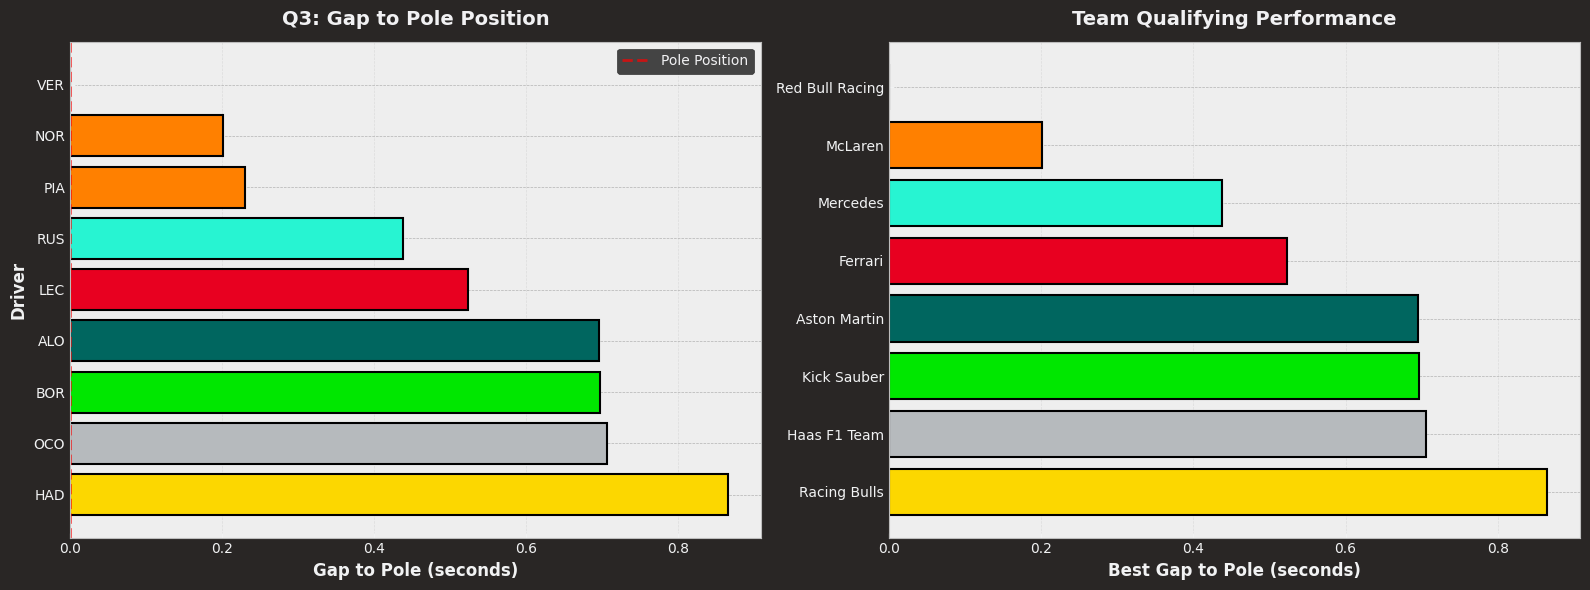


📈 QUALIFYING INSIGHTS:
Pole position: VER (Red Bull Racing)
Pole time: 1:22.207
Gap P1-P2: 0.201s
Gap P1-P9 (HAD): 0.865s
Closest battle: Top 3 within 0.230s
Note: TSU made Q3 but did not set a valid lap time.


In [50]:
# Create qualifying gaps visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Bar chart of gaps to pole
# FIX: Updated to get_team_color() and passed the 'quali' session object
colors = [fastf1.plotting.get_team_color(team, session=quali) for team in fastest_q3.head(10)['TeamName']]

ax1.barh(fastest_q3.head(10)['Abbreviation'], fastest_q3.head(10)['GapToPole'], color=colors, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('Gap to Pole (seconds)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Driver', fontsize=12, fontweight='bold')
ax1.set_title('Q3: Gap to Pole Position', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)
ax1.axvline(0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Pole Position')
ax1.legend()

# Plot 2: Team comparison
team_best = fastest_q3.groupby('TeamName')['GapToPole'].min().sort_values().head(10)
# FIX: Updated to get_team_color() and passed the 'quali' session object
team_colors = [fastf1.plotting.get_team_color(team, session=quali) for team in team_best.index]

ax2.barh(range(len(team_best)), team_best.values, color=team_colors, edgecolor='black', linewidth=1.5)
ax2.set_yticks(range(len(team_best)))
ax2.set_yticklabels(team_best.index)
ax2.set_xlabel('Best Gap to Pole (seconds)', fontsize=12, fontweight='bold')
ax2.set_title('Team Qualifying Performance', fontsize=14, fontweight='bold')
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Print key stats
print(f"\n📈 QUALIFYING INSIGHTS:")
print(f"Pole position: {fastest_q3.iloc[0]['Abbreviation']} ({fastest_q3.iloc[0]['TeamName']})")

pole_time_str = str(fastest_q3.iloc[0]['Q3']).split('00:0')[1][:8]
print(f"Pole time: {pole_time_str}")

print(f"Gap P1-P2: {fastest_q3.iloc[1]['GapToPole']:.3f}s")

# FIX: Dynamically find the last driver who actually set a time
last_idx = len(fastest_q3) - 1
print(f"Gap P1-P{last_idx + 1} ({fastest_q3.iloc[last_idx]['Abbreviation']}): {fastest_q3.iloc[last_idx]['GapToPole']:.3f}s")

print(f"Closest battle: Top 3 within {fastest_q3.iloc[2]['GapToPole']:.3f}s")

# Bonus: Check if anyone made Q3 but didn't set a time
q3_all = quali.results[quali.results['Q3'].isnull() & (quali.results['Position'] <= 10)]
if not q3_all.empty:
    no_time_drivers = ", ".join(q3_all['Abbreviation'].tolist())
    print(f"Note: {no_time_drivers} made Q3 but did not set a valid lap time.")

---
# 2️⃣ Race Analysis

## 🏁 Race Results & Performance

In [51]:
# Get race results
results = race.results
results_sorted = results.sort_values('Position').head(10)

print("🏆 Abu Dhabi GP 2025 - RACE RESULTS")
print("="*80)
print(f"{'Pos':<4} {'Driver':<20} {'Team':<20} {'Grid':<6} {'Points':<7} {'Status'}")
print("="*80)

for _, row in results_sorted.iterrows():
    grid_pos = f"P{int(row['GridPosition'])}" if not pd.isna(row['GridPosition']) else "N/A"
    print(f"{int(row['Position']):<4} {row['FullName']:<20} {row['TeamName']:<20} {grid_pos:<6} {int(row['Points']):<7} {row['Status']}")

# Calculate positions gained/lost
# Calculate positions gained/lost
results['PositionChange'] = results['GridPosition'] - results['Position']
biggest_gain = results.loc[results['PositionChange'].idxmax()]
biggest_loss = results.loc[results['PositionChange'].idxmin()]

# FIX: Find the fastest lap from the laps data, then match it to the driver
fastest_lap = race.laps.pick_fastest()
fastest_driver_abbr = fastest_lap['Driver']
fastest_driver_row = results[results['Abbreviation'] == fastest_driver_abbr].iloc[0]

print(f"\n📊 RACE HIGHLIGHTS:")
print(f"Winner: {results_sorted.iloc[0]['FullName']} ({results_sorted.iloc[0]['TeamName']})")

# Clean up the LapTime string for display
fastest_time_str = str(fastest_lap['LapTime']).split('00:0')[1][:8]
print(f"Fastest lap: {fastest_driver_row['FullName']} ({fastest_time_str})")

print(f"Biggest gain: {biggest_gain['FullName']} (+{int(biggest_gain['PositionChange'])} positions)")
print(f"Biggest loss: {biggest_loss['FullName']} ({int(biggest_loss['PositionChange'])} positions)")

🏆 Abu Dhabi GP 2025 - RACE RESULTS
Pos  Driver               Team                 Grid   Points  Status
1    Max Verstappen       Red Bull Racing      P1     25      Finished
2    Oscar Piastri        McLaren              P3     18      Finished
3    Lando Norris         McLaren              P2     15      Finished
4    Charles Leclerc      Ferrari              P5     12      Finished
5    George Russell       Mercedes             P4     10      Finished
6    Fernando Alonso      Aston Martin         P6     8       Finished
7    Esteban Ocon         Haas F1 Team         P8     6       Finished
8    Lewis Hamilton       Ferrari              P16    4       Finished
9    Nico Hulkenberg      Kick Sauber          P18    2       Finished
10   Lance Stroll         Aston Martin         P15    1       Finished

📊 RACE HIGHLIGHTS:
Winner: Max Verstappen (Red Bull Racing)
Fastest lap: Charles Leclerc (1:26.725)
Biggest gain: Nico Hulkenberg (+9 positions)
Biggest loss: Isack Hadjar (-8 positions

### 📊 Position Changes: Grid vs Finish

In [52]:
# Visualize position changes
fig = go.Figure()

# Filter to drivers who finished
finished = results[results['Position'] <= 20].copy()
finished = finished.sort_values('Position')

for _, driver in finished.iterrows():
    color = 'green' if driver['PositionChange'] > 0 else 'red' if driver['PositionChange'] < 0 else 'gray'

    fig.add_trace(go.Scatter(
        x=[0, 1],
        y=[driver['GridPosition'], driver['Position']],
        mode='lines+markers+text',
        name=driver['Abbreviation'],
        line=dict(color=color, width=2),
        marker=dict(size=10),
        text=['', driver['Abbreviation']],
        textposition='middle right',
        hovertemplate=f"<b>{driver['FullName']}</b><br>" +
                     f"Grid: P{int(driver['GridPosition'])}<br>" +
                     f"Finish: P{int(driver['Position'])}<br>" +
                     f"Change: {'+' if driver['PositionChange'] > 0 else ''}{int(driver['PositionChange'])}<br>" +
                     "<extra></extra>"
    ))

fig.update_layout(
    title='Abu Dhabi GP 2025: Grid Position vs Final Position',
    xaxis=dict(
        tickmode='array',
        tickvals=[0, 1],
        ticktext=['Grid', 'Finish'],
        range=[-0.1, 1.3]
    ),
    yaxis=dict(
        title='Position',
        autorange='reversed'
    ),
    showlegend=False,
    height=800,
    template='plotly_white'
)

fig.show()

print("💡 Green lines = positions gained | Red lines = positions lost")

💡 Green lines = positions gained | Red lines = positions lost


---
# 3️⃣ Lap Time Analysis

## ⏱️ Race Pace Comparison

In [53]:
# Get lap times for top 5 finishers
top_5_drivers = results_sorted.head(5)['Abbreviation'].tolist()

# Filter laps for top 5
top_5_laps = race.laps[race.laps['Driver'].isin(top_5_drivers)].copy()

# Convert lap time to seconds
top_5_laps['LapTimeSeconds'] = top_5_laps['LapTime'].dt.total_seconds()

# Remove outliers (pit stops, slow laps)
top_5_laps = top_5_laps[top_5_laps['LapTimeSeconds'] < 100]

print("⏱️ AVERAGE RACE PACE (Top 5 Finishers)")
print("="*60)

for driver in top_5_drivers:
    driver_laps = top_5_laps[top_5_laps['Driver'] == driver]
    avg_pace = driver_laps['LapTimeSeconds'].mean()
    fastest_lap = driver_laps['LapTimeSeconds'].min()

    print(f"{driver}: Avg {avg_pace:.3f}s | Fastest {fastest_lap:.3f}s")

⏱️ AVERAGE RACE PACE (Top 5 Finishers)
VER: Avg 88.746s | Fastest 87.625s
PIA: Avg 88.977s | Fastest 86.765s
NOR: Avg 88.669s | Fastest 86.818s
LEC: Avg 88.792s | Fastest 86.725s
RUS: Avg 89.589s | Fastest 88.599s


In [54]:
import plotly.graph_objects as go

# Visualize lap times throughout the race
fig = go.Figure()

for driver in top_5_drivers:
    driver_laps = top_5_laps[top_5_laps['Driver'] == driver]
    driver_info = results[results['Abbreviation'] == driver].iloc[0]
    team = driver_info['TeamName']

    # FIX 1: Updated to get_team_color() and passed the 'race' session object
    color = fastf1.plotting.get_team_color(team, session=race)

    fig.add_trace(go.Scatter(
        x=driver_laps['LapNumber'],
        y=driver_laps['LapTimeSeconds'],
        mode='lines',
        name=f"{driver} ({team})",
        # FIX 2: Removed the extra '#' string formatting since FastF1 provides it
        line=dict(color=color, width=2),
        hovertemplate='<b>%{fullData.name}</b><br>' +
                      'Lap %{x}<br>' +
                      'Time: %{y:.3f}s<br>' +
                      '<extra></extra>'
    ))

fig.update_layout(
    title='Abu Dhabi GP 2025: Lap Time Evolution (Top 5)',
    xaxis_title='Lap Number',
    yaxis_title='Lap Time (seconds)',
    hovermode='x unified',
    height=600,
    template='plotly_white',
    legend=dict(y=1, x=1, xanchor='right', yanchor='top')
)

fig.show()

print("💡 Spikes in lap times indicate pit stops or traffic")

💡 Spikes in lap times indicate pit stops or traffic


### 📦 Tire Strategy Analysis

In [55]:
# Analyze tire strategies
stints = race.laps[['Driver', 'Stint', 'Compound', 'LapNumber']].copy()
stints = stints.groupby(['Driver', 'Stint', 'Compound']).agg({'LapNumber': ['min', 'max', 'count']}).reset_index()
stints.columns = ['Driver', 'Stint', 'Compound', 'StartLap', 'EndLap', 'StintLength']

print("🛞 TIRE STRATEGY - Top 5 Finishers")
print("="*70)

for driver in top_5_drivers:
    driver_stints = stints[stints['Driver'] == driver]
    print(f"\n{driver}:")
    for _, stint in driver_stints.iterrows():
        compound = stint['Compound']
        print(f"  Stint {int(stint['Stint'])}: {compound:7s} | Laps {int(stint['StartLap']):2d}-{int(stint['EndLap']):2d} ({int(stint['StintLength'])} laps)")

🛞 TIRE STRATEGY - Top 5 Finishers

VER:
  Stint 1: MEDIUM  | Laps  1-23 (23 laps)
  Stint 2: HARD    | Laps 24-58 (35 laps)

PIA:
  Stint 1: HARD    | Laps  1-41 (41 laps)
  Stint 2: MEDIUM  | Laps 42-58 (17 laps)

NOR:
  Stint 1: MEDIUM  | Laps  1-16 (16 laps)
  Stint 2: HARD    | Laps 17-40 (24 laps)
  Stint 3: HARD    | Laps 41-58 (18 laps)

LEC:
  Stint 1: MEDIUM  | Laps  1-16 (16 laps)
  Stint 2: HARD    | Laps 17-39 (23 laps)
  Stint 3: MEDIUM  | Laps 40-58 (19 laps)

RUS:
  Stint 1: MEDIUM  | Laps  1-14 (14 laps)
  Stint 2: HARD    | Laps 15-58 (44 laps)


---
# 4️⃣ Telemetry Deep Dive

## 🔬 Fastest Lap Analysis

Let's analyze the telemetry data from the fastest lap to understand what makes a lap so quick.

In [56]:
# Get fastest lap of the race
fastest_lap = race.laps.pick_fastest()
fastest_driver = fastest_lap['Driver']
fastest_time = fastest_lap['LapTime']

print(f"🚀 FASTEST LAP OF THE RACE")
print(f"Driver: {fastest_driver}")
print(f"Time: {str(fastest_time)[10:22]}")
print(f"Lap: {fastest_lap['LapNumber']}")

# Get telemetry data
telemetry = fastest_lap.get_telemetry()

print(f"\n📊 Telemetry data points: {len(telemetry)}")

🚀 FASTEST LAP OF THE RACE
Driver: LEC
Time: 01:26.725000
Lap: 45.0

📊 Telemetry data points: 666


### 🗺️ Speed Trace Around the Circuit

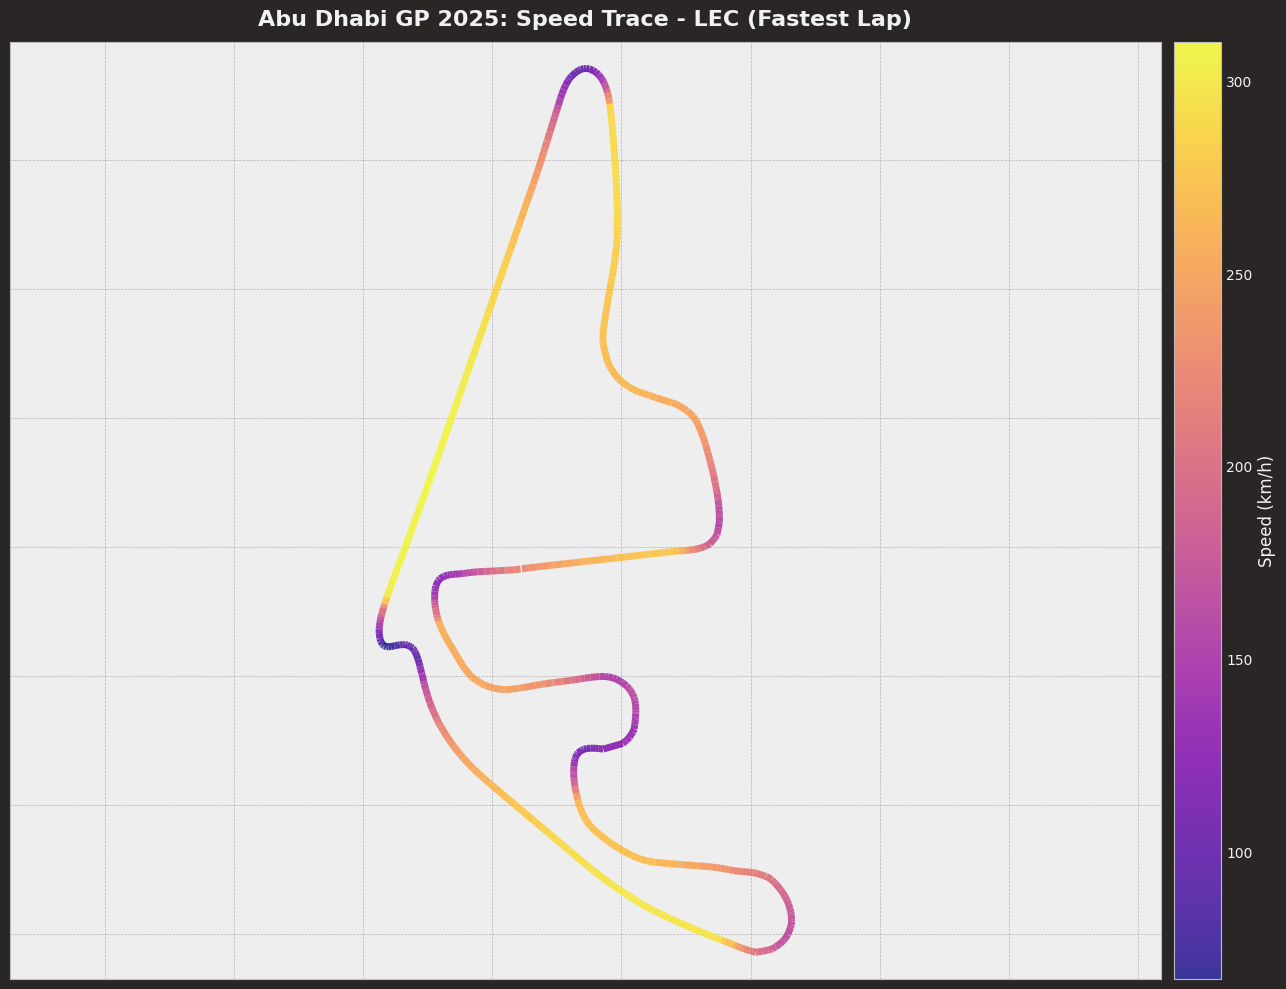

💡 Purple = High speed | Yellow = Slow corners
Max speed: 310 km/h
Min speed: 67 km/h


In [57]:
# Create speed visualization on track map
x = telemetry['X'].values
y = telemetry['Y'].values
speed = telemetry['Speed'].values

# Create points
points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# Create the line collection
fig, ax = plt.subplots(figsize=(14, 10))

# Color map
cmap = cm.plasma
lc_comp = LineCollection(segments, cmap=cmap, norm=plt.Normalize(speed.min(), speed.max()), linewidth=5, alpha=0.8)
lc_comp.set_array(speed)

# Add to plot
ax.add_collection(lc_comp)
ax.axis('equal')
ax.tick_params(labelleft=False, left=False, labelbottom=False, bottom=False)
ax.set_title(f'Abu Dhabi GP 2025: Speed Trace - {fastest_driver} (Fastest Lap)', fontsize=16, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(lc_comp, ax=ax, label='Speed (km/h)', pad=0.01)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

print(f"💡 Purple = High speed | Yellow = Slow corners")
print(f"Max speed: {speed.max():.0f} km/h")
print(f"Min speed: {speed.min():.0f} km/h")

### ⚡ Speed, Throttle, and Brake Analysis

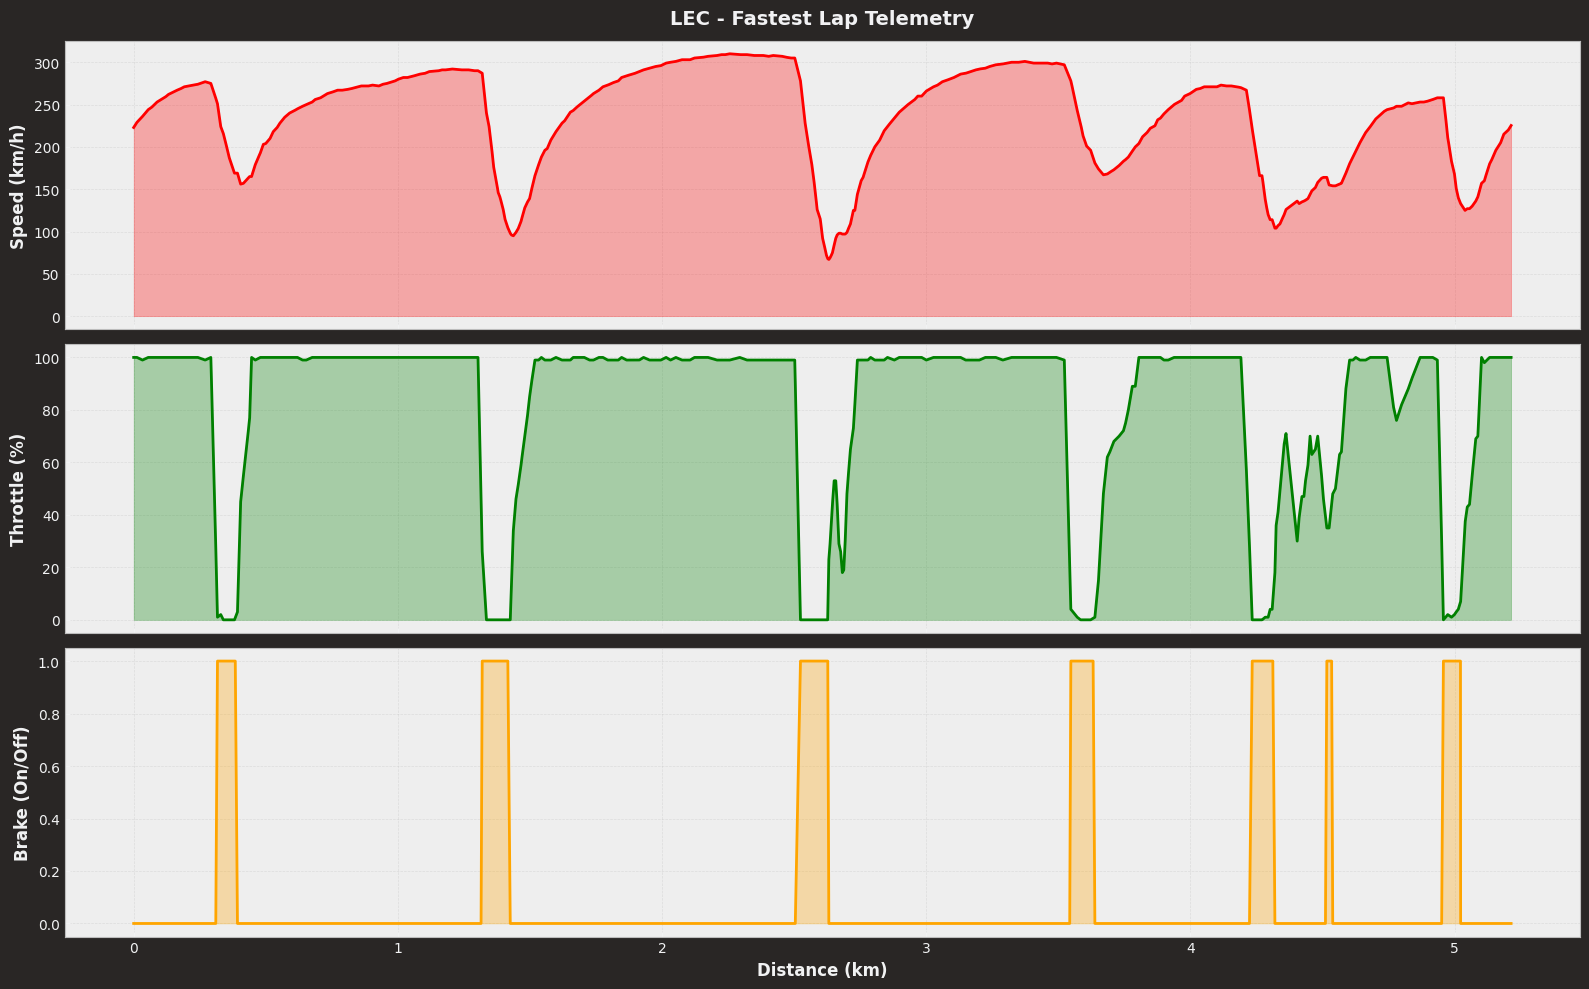

📊 TELEMETRY INSIGHTS:
Average speed: 217.4 km/h
Time at full throttle: 36.8%
Number of brake applications: 14


In [58]:
# Plot speed, throttle, and brake throughout the lap
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# Distance array
distance = telemetry['Distance'].values / 1000  # Convert to km

# Speed
ax1.plot(distance, telemetry['Speed'], color='red', linewidth=2)
ax1.set_ylabel('Speed (km/h)', fontsize=12, fontweight='bold')
ax1.set_title(f'{fastest_driver} - Fastest Lap Telemetry', fontsize=14, fontweight='bold')
ax1.grid(alpha=0.3)
ax1.fill_between(distance, telemetry['Speed'], alpha=0.3, color='red')

# Throttle
ax2.plot(distance, telemetry['Throttle'], color='green', linewidth=2)
ax2.set_ylabel('Throttle (%)', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.3)
ax2.fill_between(distance, telemetry['Throttle'], alpha=0.3, color='green')

# Brake
ax3.plot(distance, telemetry['Brake'], color='orange', linewidth=2)
ax3.set_xlabel('Distance (km)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Brake (On/Off)', fontsize=12, fontweight='bold')
ax3.grid(alpha=0.3)
ax3.fill_between(distance, telemetry['Brake'], alpha=0.3, color='orange')

plt.tight_layout()
plt.show()

print("📊 TELEMETRY INSIGHTS:")
print(f"Average speed: {telemetry['Speed'].mean():.1f} km/h")
print(f"Time at full throttle: {(telemetry['Throttle'] == 100).sum() / len(telemetry) * 100:.1f}%")
print(f"Number of brake applications: {telemetry['Brake'].diff().fillna(0).clip(lower=0).sum():.0f}")

---
# 5️⃣ Driver Comparison

## 👥 Head-to-Head: Fastest Laps Comparison

In [59]:
# Compare fastest laps between two drivers
driver_1 = 'VER'  # Change as needed
driver_2 = 'NOR'  # Change as needed

print(f"🆚 DRIVER COMPARISON: {driver_1} vs {driver_2}\n")

# Get fastest laps
lap_1 = race.laps.pick_driver(driver_1).pick_fastest()
lap_2 = race.laps.pick_driver(driver_2).pick_fastest()

print(f"{driver_1}: {str(lap_1['LapTime'])[10:22]}")
print(f"{driver_2}: {str(lap_2['LapTime'])[10:22]}")

# Get telemetry
tel_1 = lap_1.get_telemetry()
tel_2 = lap_2.get_telemetry()

# Align telemetry by distance
delta_time, ref_tel, compare_tel = fastf1.utils.delta_time(lap_1, lap_2)

print(f"\nMaximum time delta: {abs(delta_time).max():.3f}s")

🆚 DRIVER COMPARISON: VER vs NOR

VER: 01:27.625000
NOR: 01:26.818000

Maximum time delta: 0.807s


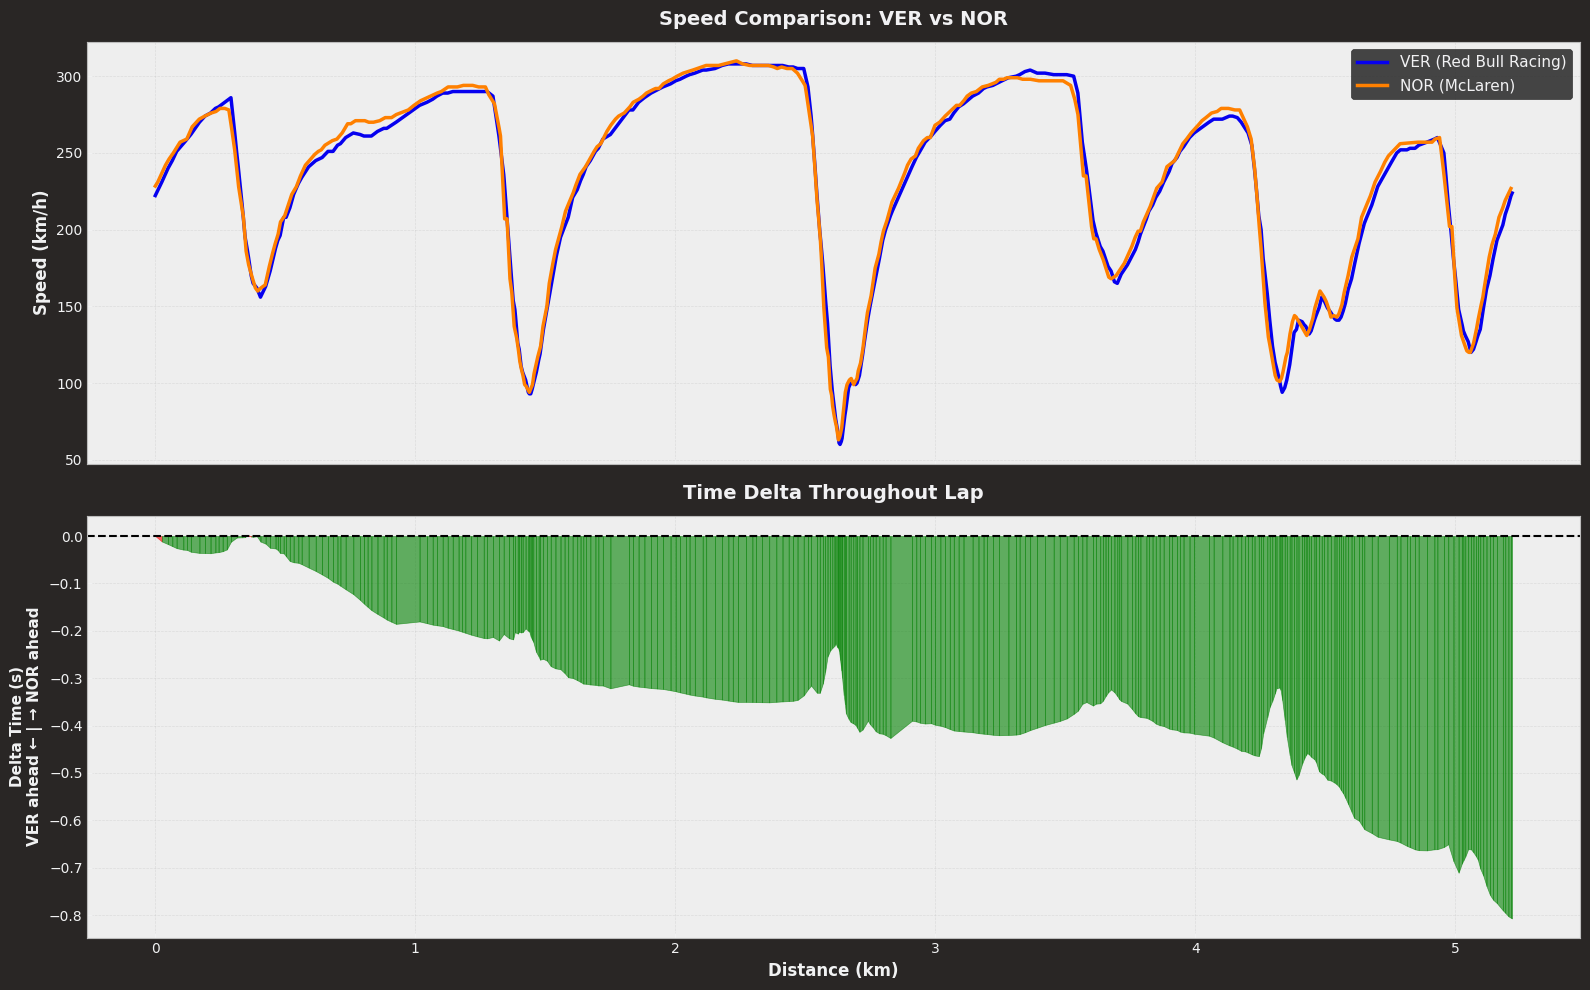


📍 SECTOR TIMES:
VER: S1=00:17.510000, S2=00:38.035000, S3=00:32.080000
NOR: S1=00:17.341000, S2=00:37.750000, S3=00:31.727000


In [60]:
# Plot speed comparison
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Distance
distance_1 = tel_1['Distance'].values / 1000
distance_2 = tel_2['Distance'].values / 1000

# Speed comparison
# FIX 1: Updated to get_team_color() and passed the session object
# (Note: replace 'race' with 'quali' if these laps are from the qualifying session)
# FIX 2: Removed the extra f"#{...}" formatting since FastF1 handles the '#'
color_1 = fastf1.plotting.get_team_color(lap_1['Team'], session=race)
color_2 = fastf1.plotting.get_team_color(lap_2['Team'], session=race)

ax1.plot(distance_1, tel_1['Speed'], color=color_1, linewidth=2.5, label=f"{driver_1} ({lap_1['Team']})")
ax1.plot(distance_2, tel_2['Speed'], color=color_2, linewidth=2.5, label=f"{driver_2} ({lap_2['Team']})")
ax1.set_ylabel('Speed (km/h)', fontsize=12, fontweight='bold')
ax1.set_title(f'Speed Comparison: {driver_1} vs {driver_2}', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=11)
ax1.grid(alpha=0.3)

# Delta time
ref_distance = ref_tel['Distance'].values / 1000
colors = ['green' if dt < 0 else 'red' for dt in delta_time]

for i in range(len(delta_time)-1):
    ax2.fill_between([ref_distance[i], ref_distance[i+1]],
                      [delta_time[i], delta_time[i+1]],
                      color=colors[i], alpha=0.6)

ax2.axhline(0, color='black', linestyle='--', linewidth=1.5)
ax2.set_xlabel('Distance (km)', fontsize=12, fontweight='bold')
ax2.set_ylabel(f'Delta Time (s)\n{driver_1} ahead ← | → {driver_2} ahead', fontsize=11, fontweight='bold')
ax2.set_title('Time Delta Throughout Lap', fontsize=14, fontweight='bold')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print sector analysis
print("\n📍 SECTOR TIMES:")
print(f"{driver_1}: S1={str(lap_1['Sector1Time'])[10:22]}, S2={str(lap_1['Sector2Time'])[10:22]}, S3={str(lap_1['Sector3Time'])[10:22]}")
print(f"{driver_2}: S1={str(lap_2['Sector1Time'])[10:22]}, S2={str(lap_2['Sector2Time'])[10:22]}, S3={str(lap_2['Sector3Time'])[10:22]}")

---
# 6️⃣ Key Insights & Conclusions

## 💡 What We Learned

In [62]:
# Generate summary statistics
print("🏆 Abu Dhabi GP 2025 - KEY TAKEAWAYS")
print("="*70)

winner = results_sorted.iloc[0]
print(f"\n1. WINNER: {winner['FullName']} ({winner['TeamName']})")
print(f"   - Started from P{int(winner['GridPosition'])}")
print(f"   - Scored {int(winner['Points'])} points")

# FIX 1: Use 'Abbreviation' (or 'FullName') and 'TeamName', plus 'Q3' for the time
pole_driver = fastest_q3.iloc[0]['Abbreviation']
pole_team = fastest_q3.iloc[0]['TeamName']
print(f"\n2. QUALIFYING: {pole_driver} took pole for {pole_team}")

# Safely extract Q3 time string
pole_time_str = str(fastest_q3.iloc[0]['Q3']).split('00:0')[1][:8]
print(f"   - Pole time: {pole_time_str}")
print(f"   - Margin to P2: {fastest_q3.iloc[1]['GapToPole']:.3f}s")

print(f"\n3. BIGGEST MOVER: {biggest_gain['FullName']}")
print(f"   - Gained {int(biggest_gain['PositionChange'])} positions")
print(f"   - Started P{int(biggest_gain['GridPosition'])}, finished P{int(biggest_gain['Position'])}")

# FIX 2: Re-use the pick_fastest() logic we established earlier
fastest_lap = race.laps.pick_fastest()
fl_driver_abbr = fastest_lap['Driver']
fl_driver_row = results[results['Abbreviation'] == fl_driver_abbr].iloc[0]

print(f"\n4. FASTEST LAP: {fl_driver_row['FullName']}")
fl_time_str = str(fastest_lap['LapTime']).split('00:0')[1][:8]
print(f"   - Time: {fl_time_str}")

# FIX 3: Filter out 'Finished' AND any status containing a '+' (like '+1 Lap')
# so we only get actual retirements (e.g., 'Engine', 'Collision')
dnf = results[~results['Status'].str.contains('Finished|\+', na=False)]
print(f"\n5. RELIABILITY: {len(dnf)} retirements")
if not dnf.empty:
    for _, driver in dnf.iterrows():
        print(f"   - {driver['FullName']}: {driver['Status']}")

print("\n" + "="*70)
print("✅ Analysis complete!")

🏆 Abu Dhabi GP 2025 - KEY TAKEAWAYS

1. WINNER: Max Verstappen (Red Bull Racing)
   - Started from P1
   - Scored 25 points

2. QUALIFYING: VER took pole for Red Bull Racing
   - Pole time: 1:22.207
   - Margin to P2: 0.201s

3. BIGGEST MOVER: Nico Hulkenberg
   - Gained 9 positions
   - Started P18, finished P9

4. FASTEST LAP: Charles Leclerc
   - Time: 1:26.725

5. RELIABILITY: 4 retirements
   - Isack Hadjar: Lapped
   - Liam Lawson: Lapped
   - Pierre Gasly: Lapped
   - Franco Colapinto: Lapped

✅ Analysis complete!


---

## 🎯 Portfolio Project Summary

**What This Analysis Demonstrates:**

1. **Data Collection** - FastF1 API expertise
2. **Data Cleaning** - Handling lap times, telemetry, and outliers
3. **Exploratory Analysis** - Understanding F1 race dynamics
4. **Visualization Skills** - Static (Matplotlib) and interactive (Plotly) charts
5. **Telemetry Analysis** - Working with high-frequency time-series data
6. **Comparative Analysis** - Driver vs driver, team vs team
7. **Domain Knowledge** - Understanding F1 strategy and performance
8. **Storytelling** - Presenting insights clearly and compellingly

**Tools Used:**
- Python, Pandas, NumPy
- Matplotlib, Seaborn, Plotly
- FastF1 library
- Jupyter Notebooks

---

**Next Steps:**
- Expand to full season analysis
- Add more driver comparisons
- Build interactive dashboard
- Add weather/track temperature analysis
- Include tire degradation modeling

---

*Created by Ibrahim | Data Analysis Portfolio | 2024*